In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [33]:
class BatsmanState(TypedDict):
    runs : int
    balls :int
    fours :int
    sixes :int

    sr: float
    bpb :float
    boundary_percent: float
    summary: str

 



In [42]:
def calc_sr(state: BatsmanState):
    sr =(state['runs']/state['balls'])*100
    
    return {'sr':sr}

In [43]:
def calc_bpb(state: BatsmanState):
    bpb=state['balls']/(state['fours']+state['sixes'])
    
    return {'bpb':bpb}


In [44]:
def calc_boundary_percent(state: BatsmanState):
    boundary_percent =(((state['fours']*4)+(state['sixes']*6))/state['runs'])*100

    
    return {'boundary_percent':boundary_percent}

In [45]:
def summary(state:BatsmanState):
    s= f"""  
Strike Rate = {state['sr']} \n
Balls Per boundry = {state['bpb']}\n
Boundary percent ={state['boundary_percent']}
"""
   
    return {"summary":s}

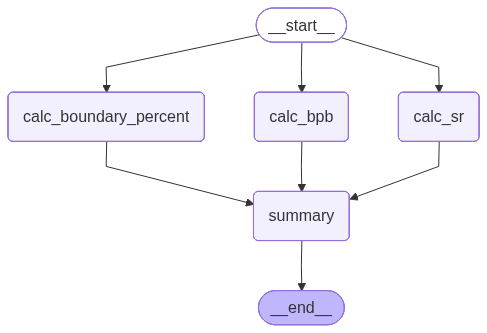

In [46]:
graph = StateGraph(BatsmanState)

## add node
graph.add_node('calc_sr', calc_sr)
graph.add_node('calc_bpb', calc_bpb)
graph.add_node('calc_boundary_percent', calc_boundary_percent)
graph.add_node('summary', summary)

## add edges 
graph.add_edge(START, 'calc_bpb')
graph.add_edge(START, 'calc_sr')
graph.add_edge(START, 'calc_boundary_percent')

graph.add_edge('calc_boundary_percent','summary')
graph.add_edge('calc_bpb','summary')
graph.add_edge('calc_sr','summary')

graph.add_edge('summary',END)

graph.compile()

In [ ]:
##when we run parrallel workflow then  we have not to send whole state 
## bcz its confused the junction node it assumes that all the nodes perdorm operation and change it so it confuses\\N
#  which part i have to take so we give only the dictonery of the state which is calculted by the output of the function 
initail_state= {'runs':100,
                 'balls':50,
           'sixes':4,
            'fours':6
               }


In [48]:
work=graph.compile()
out=work.invoke(initail_state)
print(out)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': '  \nStrike Rate = 200.0 \n\nBalls Per boundry = 5.0\n\nBoundary percent =48.0\n'}


In [49]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from typing import TypedDict
from pydantic import BaseModel, Field
import google.generativeai as genai

c:\Users\VICTUS\Desktop\langraph1\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\TEMP\ipykernel_32128\3017303531.py:6: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai
